In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from termcolor import cprint
from pathlib import Path
import pandas as pd
import os
import results_analysis_utils as rutils
import matplotlib.pyplot as plt
import seaborn as sn

%load_ext autoreload
%autoreload 2


# Configuración estética para artículos científicos (Paper-ready)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.dpi'] = 200 # Alta resolución
plt.rcParams['savefig.dpi'] = 200

one_fish_gt = {"2024_11_12":31.5, "2024_11_28":28.9,"2025_05_08":33.5,"2025_08_21":29.1}

# Choose video day
folder_code ="2024_11_12"

# Parámetros Globales
ROOT_DIR = "/home/slimbook/fish_sizing/ARTICLE/1_peix/"+folder_code
ASPECT_RATIO_THR = 3.0
ANGLE_THR = 20.0

df=[]

cprint(f"Processing fish videos recorded on the date {folder_code} ","blue")
cprint(f"ROOT DIR IS {ROOT_DIR} ","blue")

gt = one_fish_gt[folder_code]
cprint(f"✅ Ground Truth is the same for all videos with a single fish: {gt}","magenta")



Processing fish videos recorded on the date 2024_11_12 
ROOT DIR IS /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12 
✅ Ground Truth is the same for all videos with a single fish: 31.5


In [2]:
df_raw_agg = rutils.create_df_from_root_folders(root_dir= ROOT_DIR, output_csv_path=ROOT_DIR ,results_dir="corrected_results", gt=None)


df_raw_agg.head()



Buscando datos RAW en: /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_44_11/0/results_article_basic_nou/corrected_results/10_44_11_0_raw.csv
FOLDER CODE IS:  10_44_11-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_54_07/0/results_article_basic_nou/corrected_results/10_54_07_0_raw.csv
FOLDER CODE IS:  10_54_07-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/11_10_50/0/results_article_basic_nou/corrected_results/11_10_50_0_raw.csv
FOLDER CODE IS:  11_10_50-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/11_00_27/0/results_article_basic_nou/corrected_results/11_00_27_0_raw.csv
FOLDER CODE IS:  11_00_27-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_11_12/10_58_20/0/results_article_basic_nou/corrected_results/10_58_20_0_raw.csv
FOLDER CODE IS:  10_58_20-0
Procesando csv:  /home/slimbook/fish_sizing/ARTICLE/1_peix/2024_

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
0,2024_11_12,10_44_11-0,frame_1,0,255,-1,1,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN
1,2024_11_12,10_44_11-0,frame_9,0,255,-1,1,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN
2,2024_11_12,10_44_11-0,frame_12,0,255,-1,0,True,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN
3,2024_11_12,10_44_11-0,frame_13,0,255,3,0,True,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN
4,2024_11_12,10_44_11-0,frame_15,0,255,3,0,True,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,31.5,NaN,NaN,NaN


In [3]:

df_3d_measures=df_raw_agg[df_raw_agg["filtered_length"] > 0]


cprint(df_raw_agg.describe(),"red")
cprint(df_3d_measures.describe(),"green")
output_path = Path(ROOT_DIR) / f"{folder_code}_raw_3d_aggregated.csv"

df_3d_measures.to_csv(output_path, index=False)
 
df_3d_measures.head()



       class_name    object_id     track_id  is_3D_complete  aspect_ratio  \
count      2170.0  2170.000000  2170.000000     2170.000000   2170.000000   
mean          0.0   251.463594    20.639631        0.891705      3.518527   
std           0.0    21.213134    16.364427        0.310824      1.128983   
min           0.0    85.000000    -1.000000        0.000000      1.017788   
25%           0.0   255.000000     6.000000        1.000000      2.873239   
50%           0.0   255.000000    16.000000        1.000000      3.537750   
75%           0.0   255.000000    38.000000        1.000000      4.120878   
max           0.0   255.000000    72.000000        1.000000     12.449745   

       elevation_deg  azimuth_deg  raw_length  filtered_length  spine_length  \
count     908.000000   908.000000  908.000000       908.000000    908.000000   
mean        5.929135    20.457837    0.359882         0.292666      0.300785   
std        30.683125    67.272349    0.861701         0.114226    

,video_day,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,is_front_fish,...,fish_direction,elevation_deg,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_cm,rel_error_%,fish_dist_from_camera
66,2024_11_12,10_44_11-0,frame_108,0,255,3,1,False,False,True,...,[ -0.047796 -0.32801 0.94346],3.714765,9.934494,2.376050,0.428248,0.424896,31.5,11.324795,35.951729,0.699576
70,2024_11_12,10_44_11-0,frame_115,0,255,3,1,False,False,True,...,NaN,-0.037580,14.808503,-1.000000,0.435934,0.436737,31.5,12.093409,38.391774,0.692552
72,2024_11_12,10_44_11-0,frame_118,0,255,3,1,False,False,True,...,NaN,2.226477,9.253469,-1.000000,0.434911,0.434006,31.5,11.991052,38.066833,0.712949
77,2024_11_12,10_44_11-0,frame_126,0,255,3,1,False,False,True,...,[ 0.50741 -0.14805 0.84889],-0.429623,15.376115,1.665510,0.429357,0.420976,31.5,11.435654,36.303662,0.692104
120,2024_11_12,10_44_11-0,frame_285,0,255,3,1,False,False,True,...,[ 0.38489 -0.41355 0.82513],3.500313,-21.627361,1.916571,0.304956,0.279093,31.5,1.004354,3.188425,0.694922


In [4]:
# Checks!

# Number of video seqs loaded:
video_codes = df_raw_agg["source_folder"].unique()
cprint(f"Number of video seqs is: {len(video_codes)}","yellow")
 
cprint("\n Unique video codes are","cyan")
for code in video_codes:
    cprint(code+ "\n","cyan")

Number of video seqs is: 9

 Unique video codes are
10_44_11-0

10_54_07-0

11_10_50-0

11_00_27-0

10_58_20-0

11_08_39-0

11_37_10-0

10_48_44-1

10_48_44-0



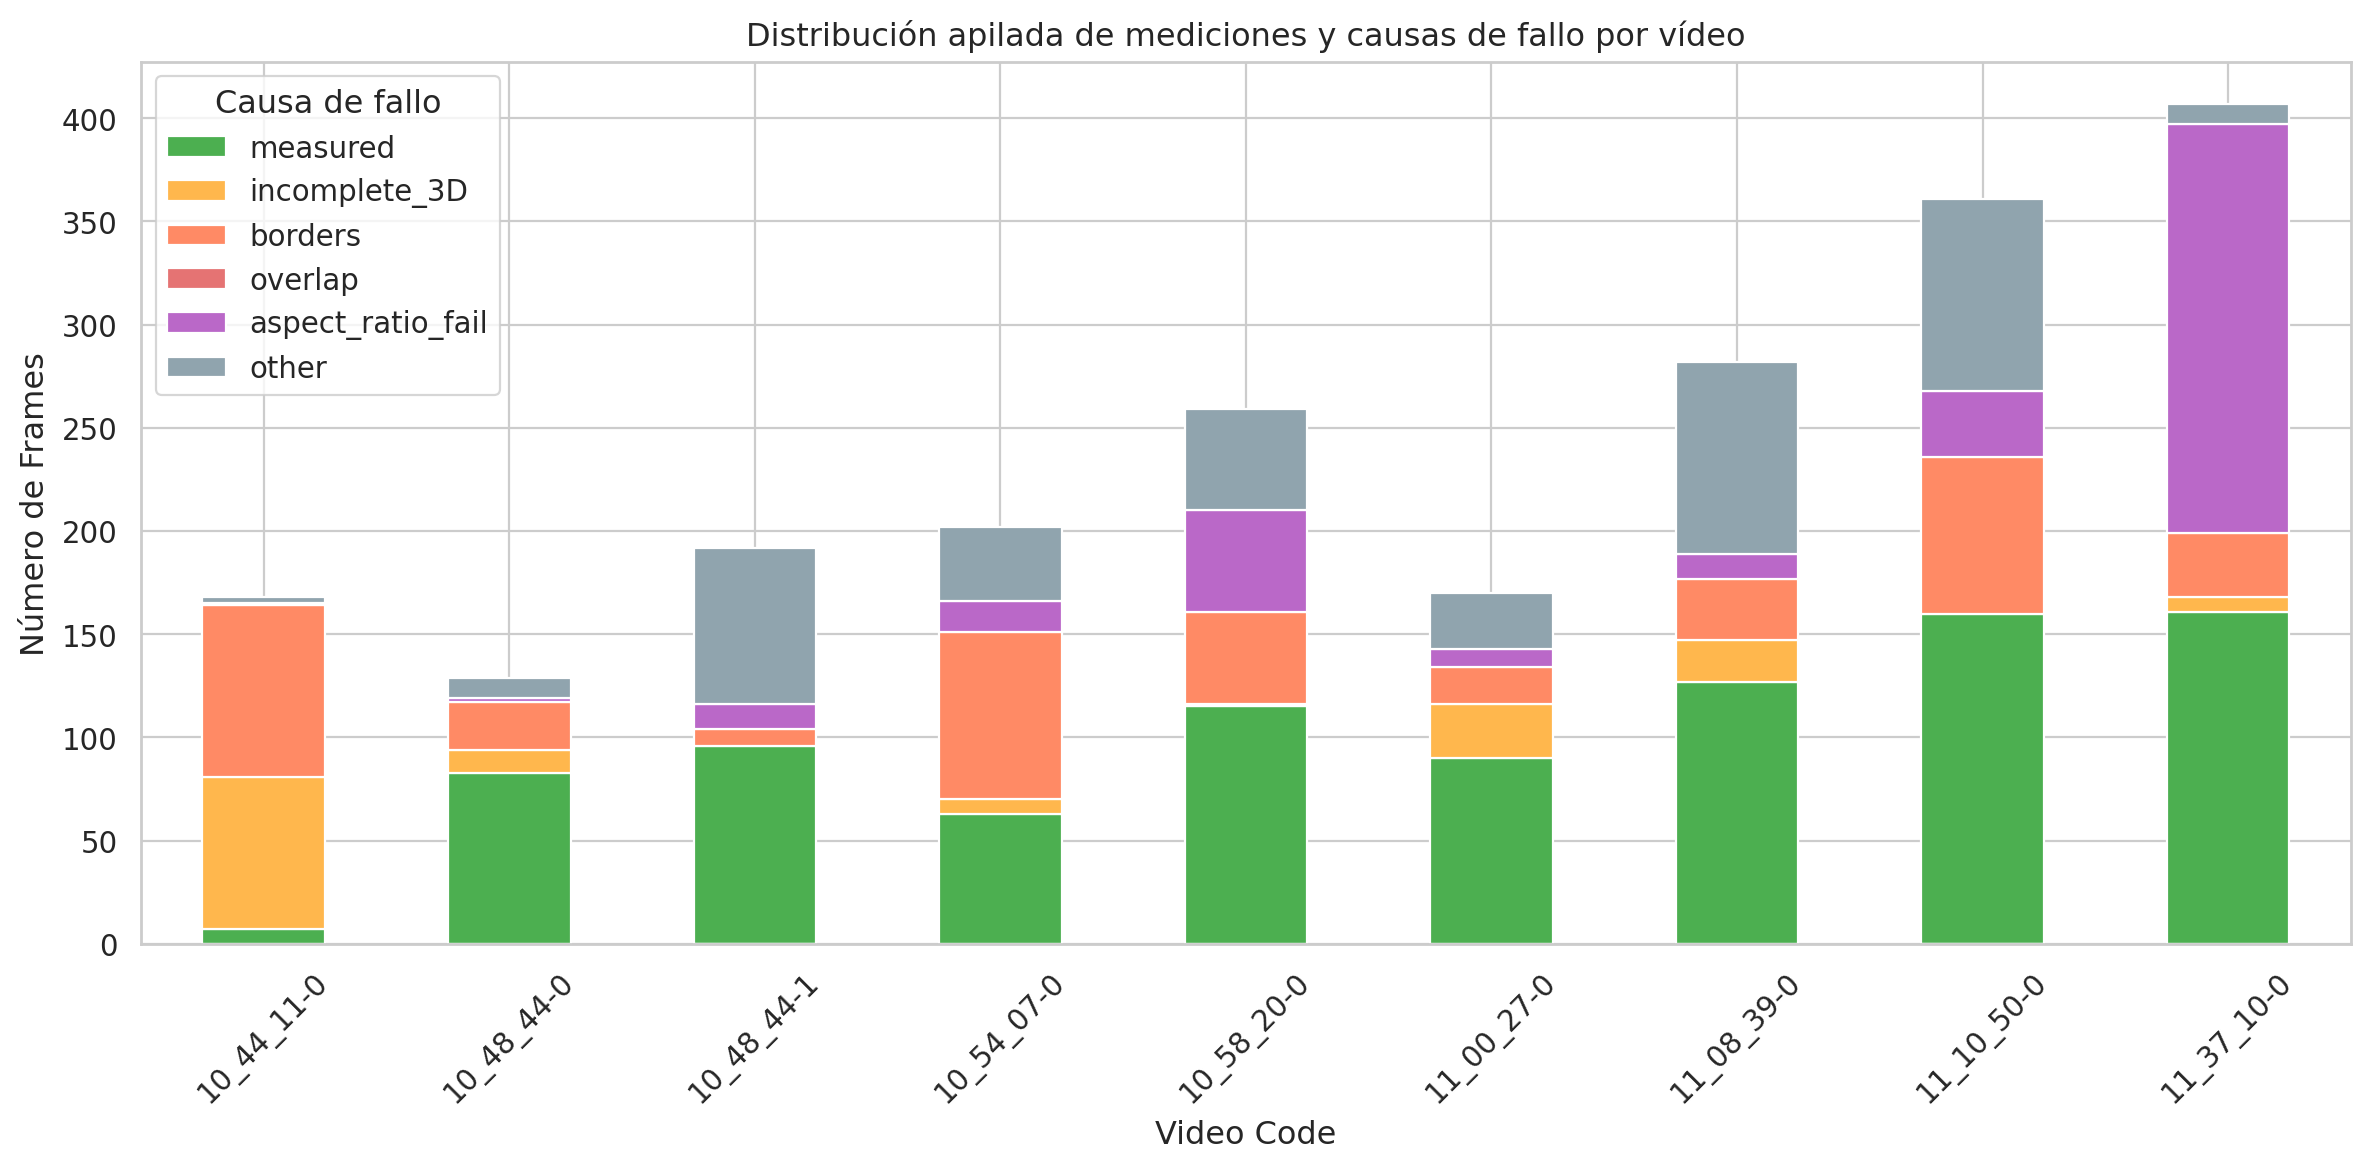

Conteo global de frames por causa:
      failure_reason  count
0           measured    902
1      incomplete_3D    146
2            borders    395
3            overlap      0
4  aspect_ratio_fail    330
5              other    397


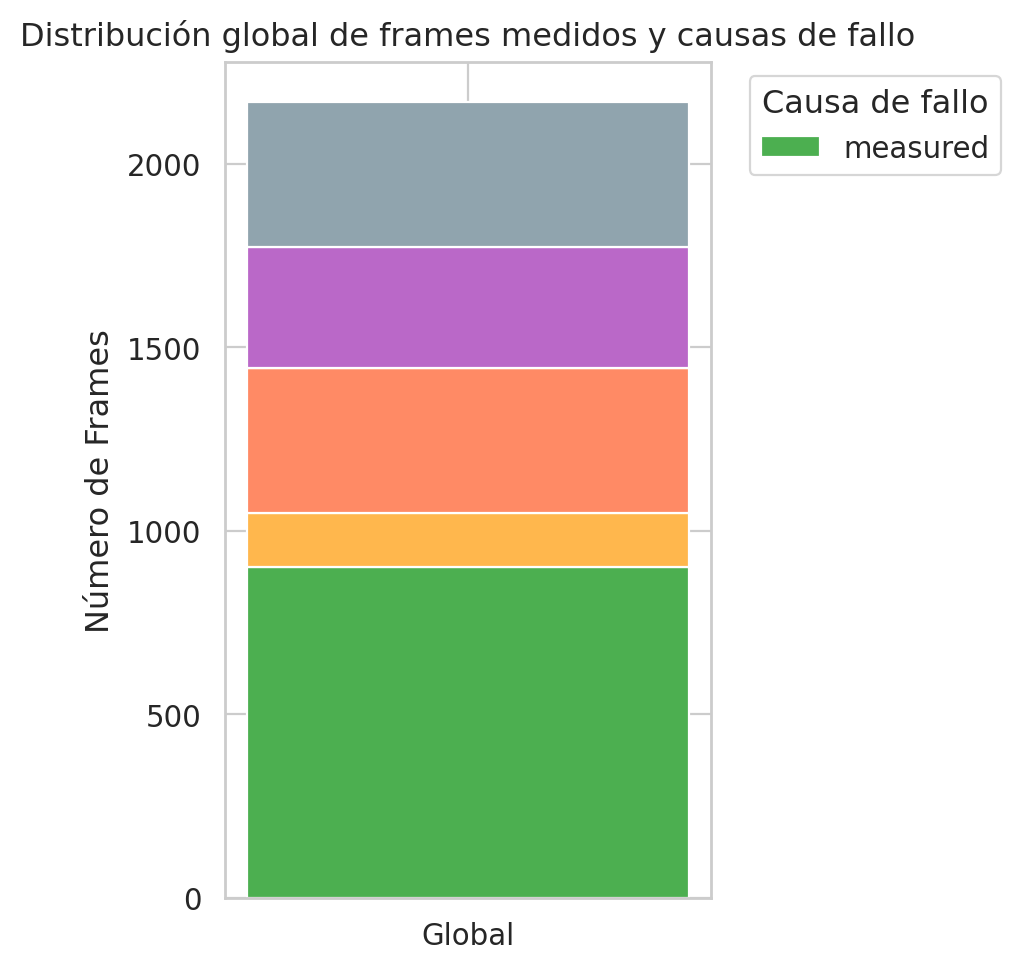

failure_reason,measured,incomplete_3D,borders,overlap,aspect_ratio_fail,other
source_folder,,,,,,
10_44_11-0,7,74,83,0,1,3
10_48_44-0,83,11,23,0,2,10
10_48_44-1,96,0,8,0,12,76
10_54_07-0,63,7,81,0,15,36
10_58_20-0,115,1,45,0,49,49
11_00_27-0,90,26,18,0,9,27
11_08_39-0,127,20,30,0,12,93
11_10_50-0,160,0,76,0,32,93
11_37_10-0,161,7,31,0,198,10


In [5]:
df_raw_agg['unique_track'] = df_raw_agg['source_folder'].astype(str) + "_" + df_raw_agg['track_id'].astype(str)
df_raw_agg["failure_reason"] = df_raw_agg.apply(
    lambda row: rutils.classify_failure(row, ASPECT_RATIO_THR=ASPECT_RATIO_THR),
    axis=1
)



rutils.plot_frame_failures(df_raw_agg, figsize_video=(12,6), figsize_global=(5,5), show_global=True)

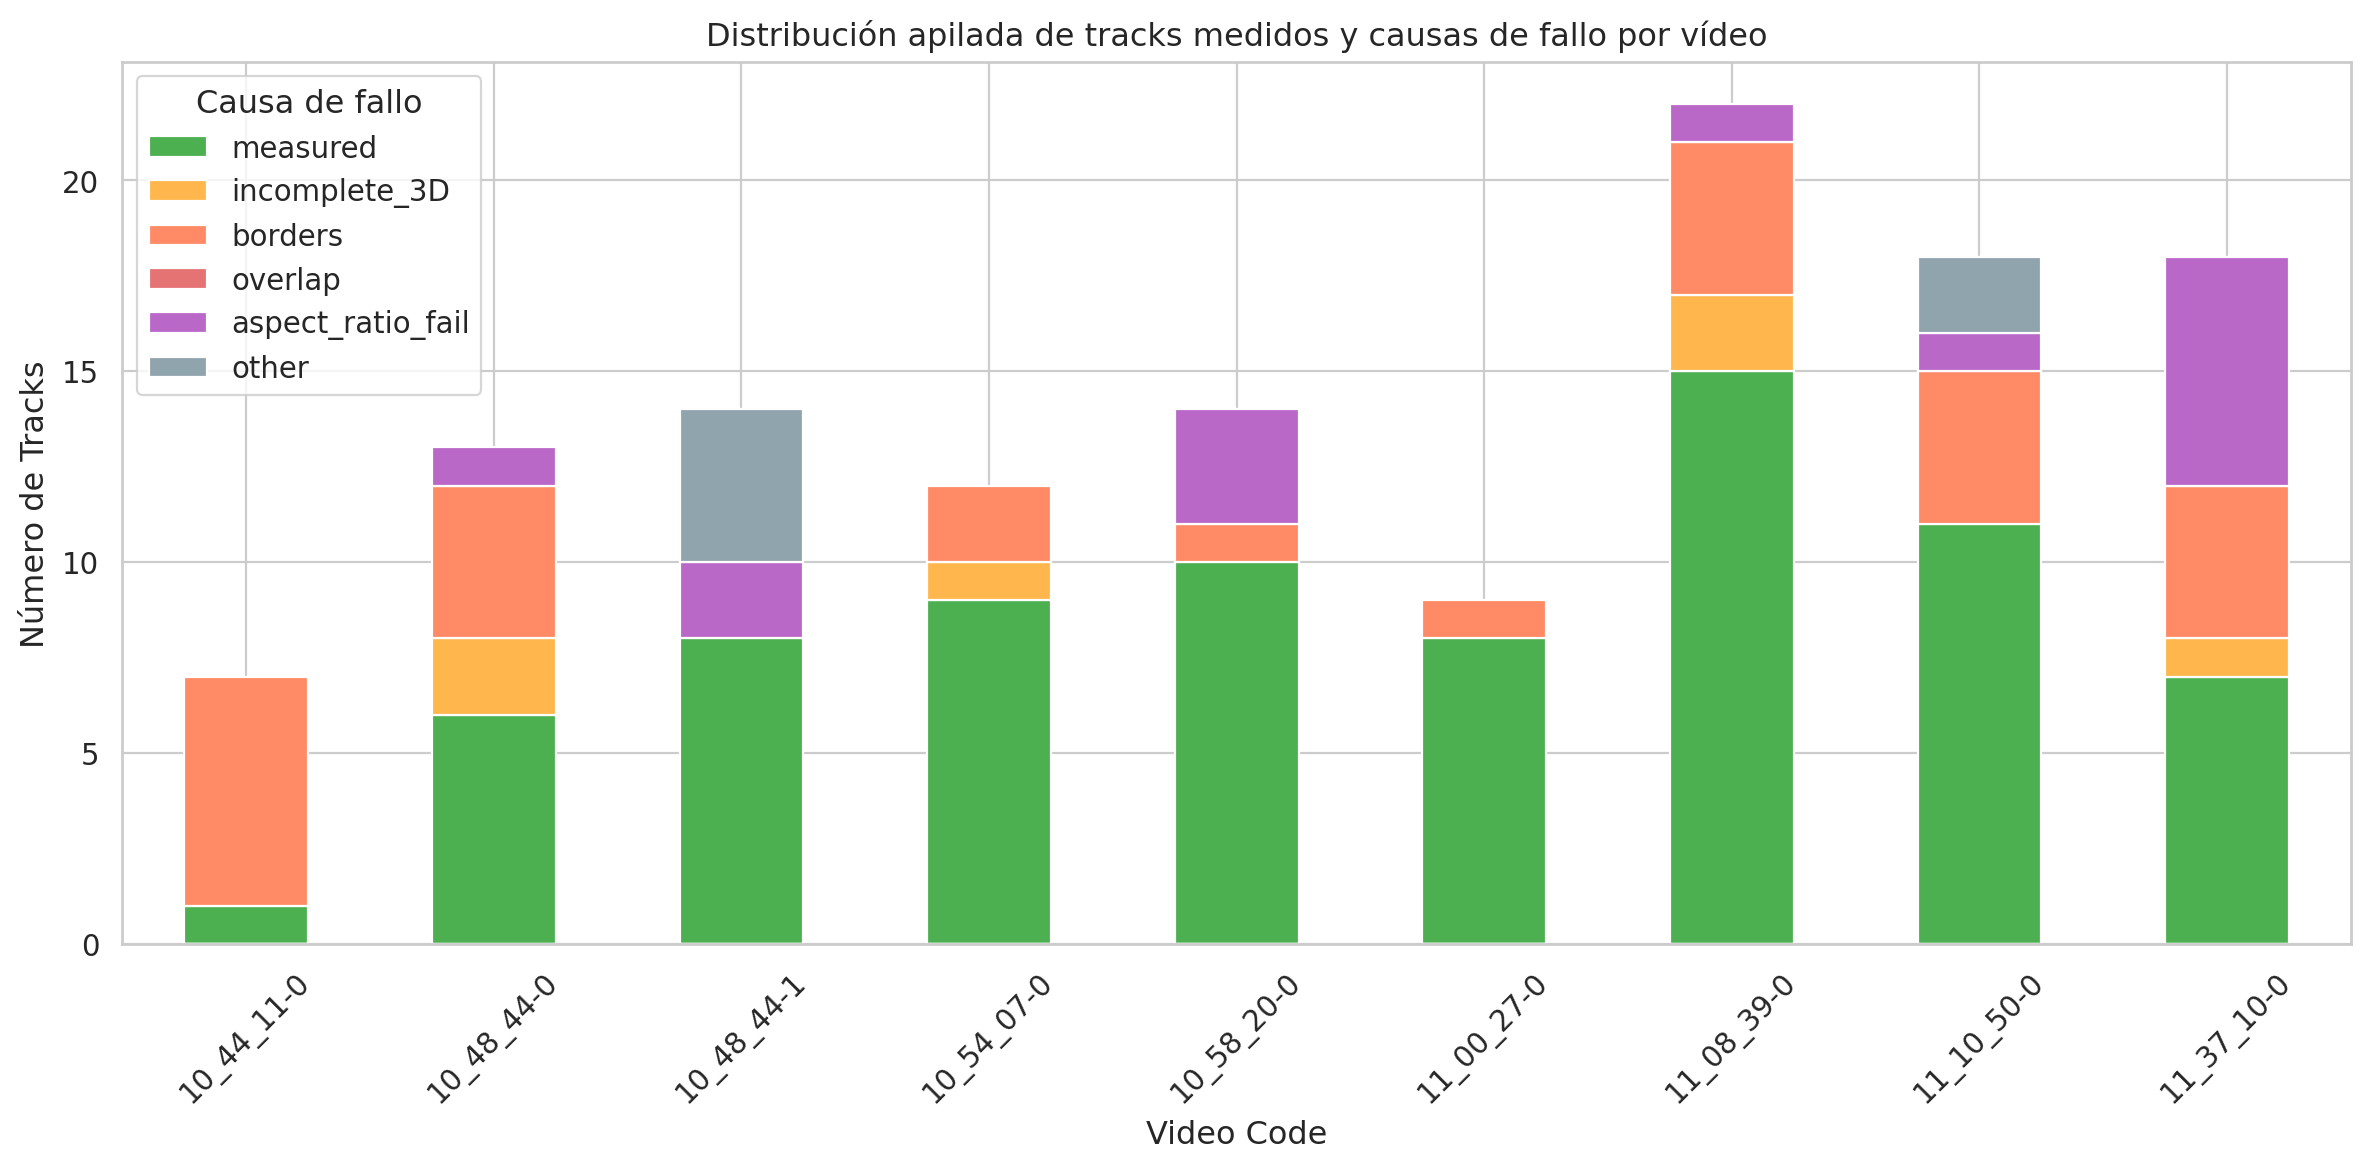

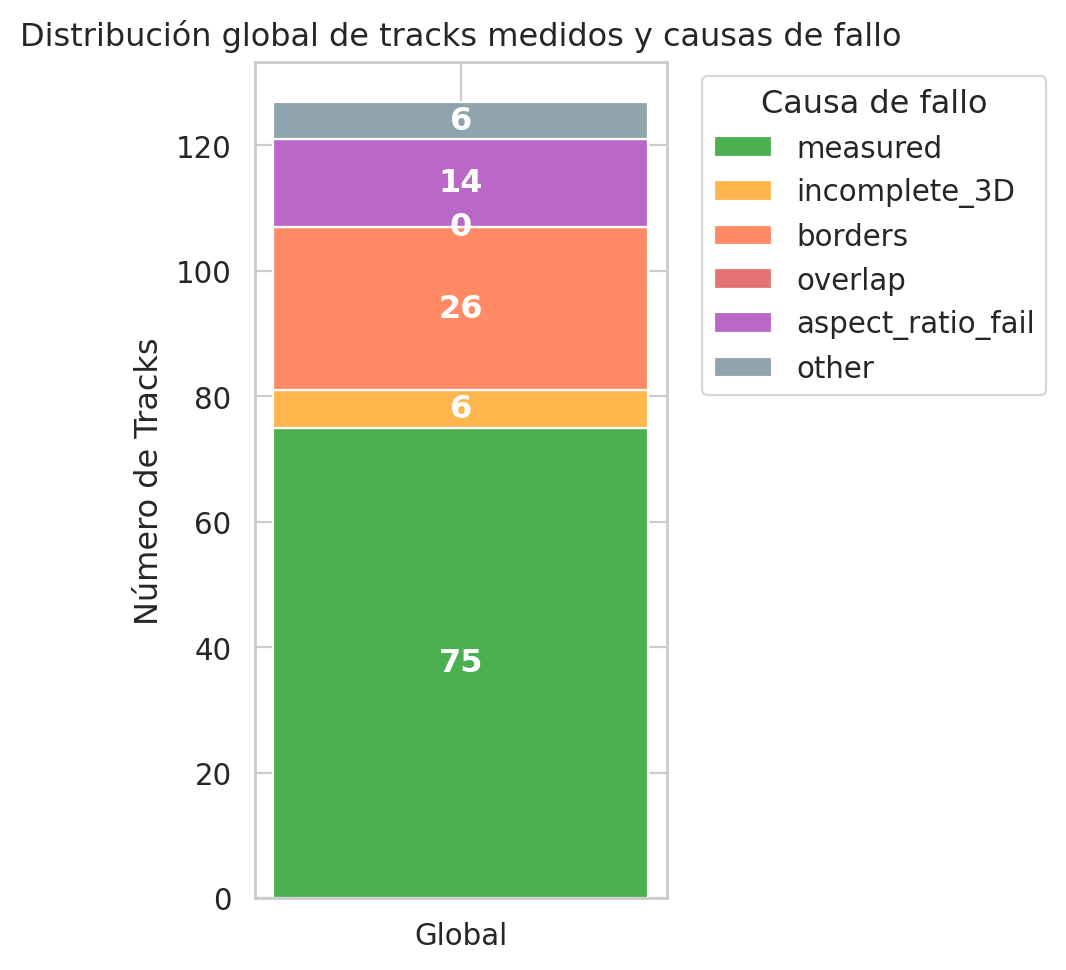

,unique_track,track_failure_reason,source_folder
0,10_44_11-0_-1,borders,10_44_11-0
1,10_44_11-0_13,borders,10_44_11-0
2,10_44_11-0_15,borders,10_44_11-0
3,10_44_11-0_3,measured,10_44_11-0
4,10_44_11-0_7,borders,10_44_11-0
...,...,...,...
122,11_37_10-0_4,aspect_ratio_fail,11_37_10-0
123,11_37_10-0_41,aspect_ratio_fail,11_37_10-0
124,11_37_10-0_44,measured,11_37_10-0
125,11_37_10-0_45,measured,11_37_10-0


In [6]:
rutils.plot_tracks_failure_distribution(df_raw_agg, aspect_ratio_thr=3.0, show_global=True, figsize_video=(12,6), figsize_global=(5,5))

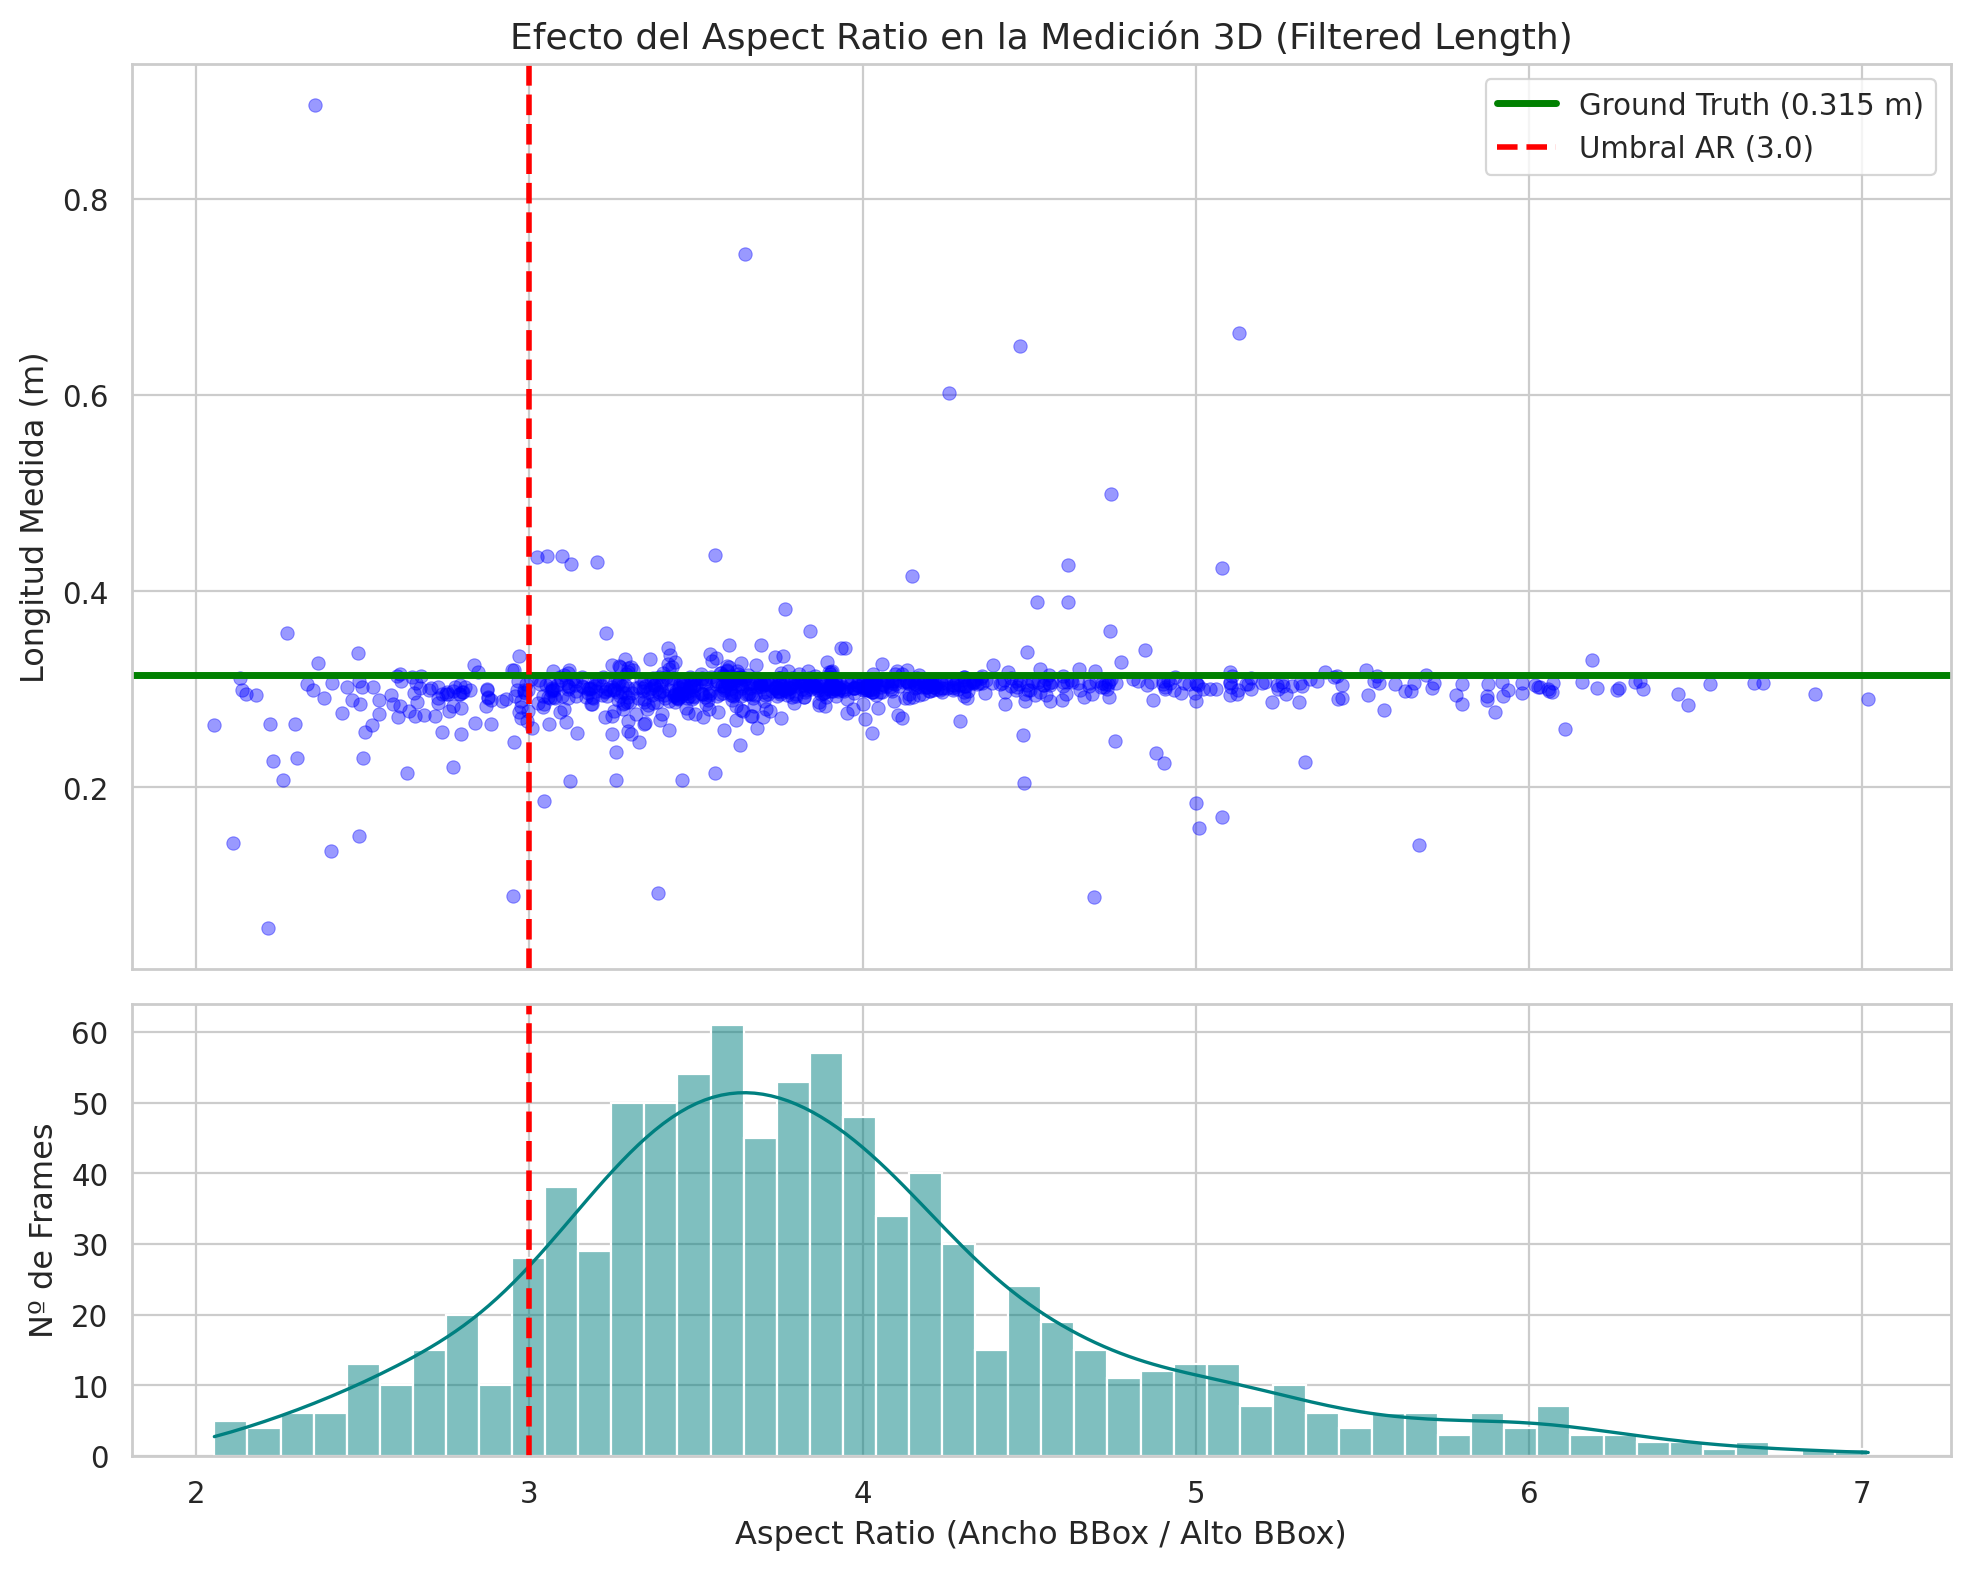

In [9]:
rutils.plot_aspect_ratio_vs_length(df_raw_agg, ASPECT_RATIO_THR=ASPECT_RATIO_THR, figsize=(10, 8))


In [ ]:
import warnings
warnings.filterwarnings('ignore')

def smart_aggregator(track_df,num_tracks_threshold=5,deviation_from_median=1.5):
    """Smart filtering to all tracks"""
    num_frames = len(track_df)
    
    # if There's not a min number of tracks do not consider this measurement
    if num_frames < num_tracks_threshold: return None
    
    sorted_lengths = track_df['filtered_length'].dropna().sort_values(ascending=False).tolist()
    if not sorted_lengths: return None
    
    valid_max = sorted_lengths[0]
    if len(sorted_lengths) >= 5:
        while len(sorted_lengths) > 2:
            c_max, n_max = sorted_lengths[0], sorted_lengths[1]
            c_med = np.median(sorted_lengths)
            
            # If maximum is further than c_med * deviation_from_median of the median consider it an outlier
            if c_max > c_med * deviation_from_median:
                sorted_lengths.pop(0); continue
            # if maximum is more thabn a 5% further than the next measure discard it
            if (c_max - n_max) / n_max < 0.05:
                valid_max = c_max; break
            else:
                sorted_lengths.pop(0)
        if len(sorted_lengths) <= 2: valid_max = sorted_lengths[0]
            
    if num_frames < 20: 
        rep_len = valid_max
    else:
        n_top = max(1, int(len(sorted_lengths) * 0.2))
        rep_len = sum(sorted_lengths[:n_top]) / n_top
        
    gt_val = track_df['gt'].iloc[0]
    rel_err = abs((rep_len - (gt_val/100.0)) * 100) / gt_val * 100 if gt_val > 0 else None
    
    return pd.Series({
        'n_frames_validos': num_frames,
        'length_used_for_error': rep_len,
        'mean_elevation_deg': track_df['elevation_deg'].mean(),
        'mean_aspect_ratio': track_df['aspect_ratio'].mean(),
        'gt': gt_val,
        'rel_error_%': rel_err
    })


# 1. PASO 1: "all_complete_ok_fish.csv"
# (Aseguramos que solo entran las detecciones impecables)
df_all_complete_ok = df_raw[
    (df_raw['is_3D_complete'] == True) &
    (df_raw['in_image_borders'] == False) &
    (df_raw['does_overlap'] == False) &
    (df_raw['aspect_ratio'] >= ASPECT_RATIO_THR) &
    (df_raw['filtered_length'] > 0)
].copy()

# 2. PASO 2: "resume_filtered_smart.csv"
# (Agrupamos los frames buenos por cada Track ID)
df_resume_smart = df_all_complete_ok.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# 3. PASO 3: "resume_filtered_smart_angle_ok.csv"
# (Aplicamos el filtro final de Ángulo Z <= 20º a los peces ya agrupados)
df_resume_smart_angle_ok = df_resume_smart[df_resume_smart['mean_elevation_deg'].abs() <= ANGLE_THR].copy()

# --- RESUMEN DE LA CASCADA ---
print("=== CASCADA DE PROCESAMIENTO ===")
print(f"1. Detecciones individuales RAW: {len(df_raw)}")
print(f"2. Detecciones individuales OK (all_complete_ok_fish): {len(df_all_complete_ok)}")
print(f"3. Peces únicos medidos tras Agrupación Smart (resume_filtered_smart): {len(df_resume_smart)}")
print(f"4. Peces finales tras filtro Ángulo <= {ANGLE_THR}º (resume_smart_angle_ok): {len(df_resume_smart_angle_ok)}")

=== CASCADA DE PROCESAMIENTO ===
1. Detecciones individuales RAW: 3309
2. Detecciones individuales OK (all_complete_ok_fish): 2864
3. Peces únicos medidos tras Agrupación Smart (resume_filtered_smart): 60
4. Peces finales tras filtro Ángulo <= 20.0º (resume_smart_angle_ok): 46


Calculando el impacto de cada filtro... (esto puede tardar unos segundos)

ETAPA DEL PIPELINE (CASCADA)                  | ERROR MEDIO     | FRAMES VIVOS    | PECES (TRACKS)
----------------------------------------------------------------------------------------------------
0. Base (HDBSCAN sin filtros)                 |  3.64 ± 7.23 cm |    3216 frames |    62 tracks
1. + Filtro: is_3D_complete                   |  3.36 ± 6.85 cm |    3168 frames |    60 tracks
2. + Filtro: Sin Bordes                       |  1.99 ± 3.81 cm |    2972 frames |    54 tracks
3. + Filtro: Sin Solapamiento                 |  1.99 ± 3.81 cm |    2972 frames |    54 tracks
4. + Filtro: Aspect Ratio >= 3.0              |  1.34 ± 1.92 cm |    2864 frames |    52 tracks
5. + Filtro: Ángulo Z <= 20.0º (Por Frame)    |  0.67 ± 1.00 cm |    2096 frames |    38 tracks


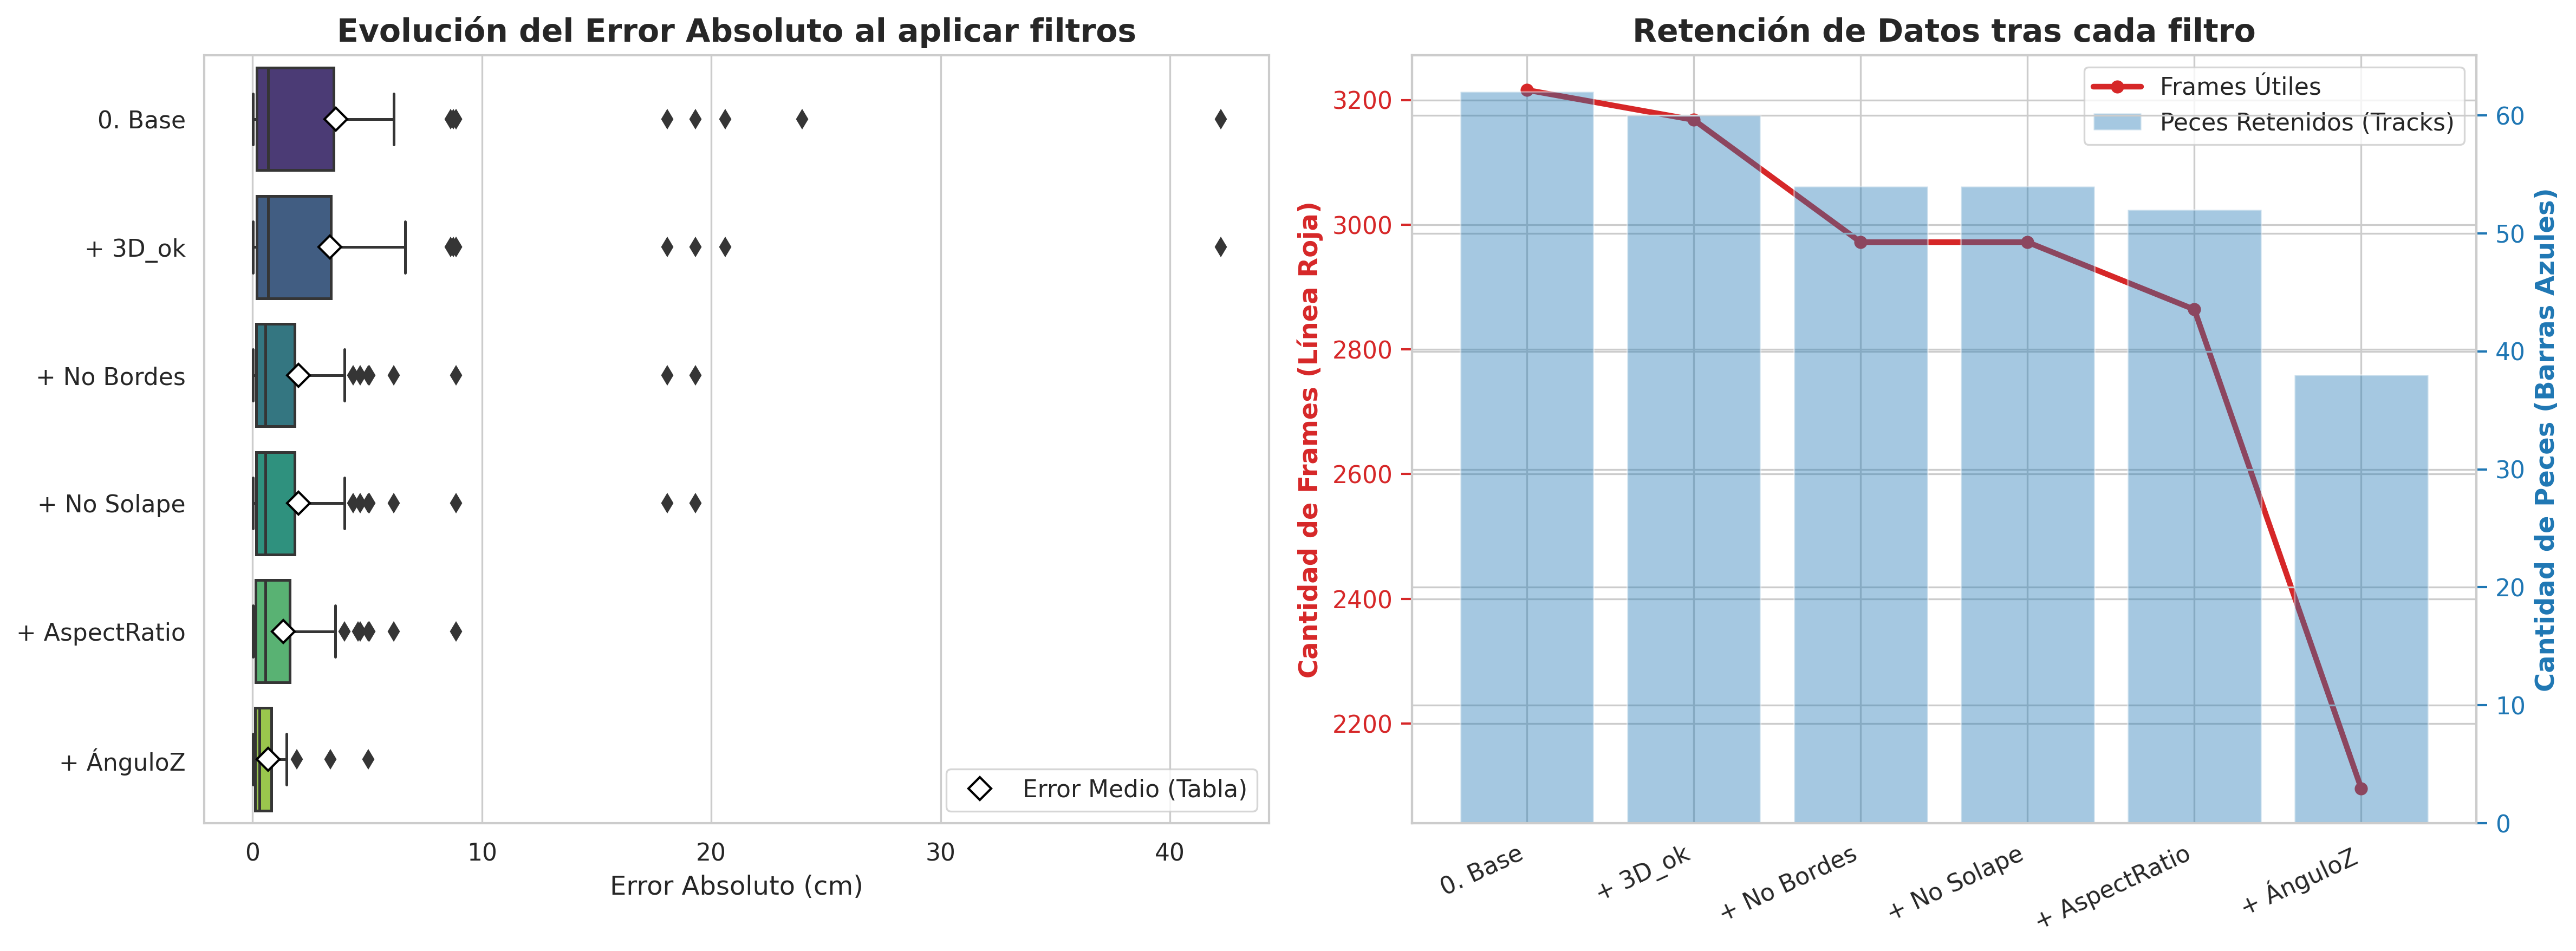

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines

# =====================================================================
# 1. LA FUNCIÓN (Aseguramos que devuelve 'abs_error_cm' en la memoria)
# =====================================================================
def smart_aggregator(track_df, length_col='filtered_length'):
    num_frames = len(track_df)
    if num_frames < 5: return None
    
    sorted_lengths = track_df[length_col].dropna().sort_values(ascending=False).tolist()
    if not sorted_lengths: return None
    
    valid_max = sorted_lengths[0]
    if len(sorted_lengths) >= 5:
        while len(sorted_lengths) > 2:
            c_max, n_max = sorted_lengths[0], sorted_lengths[1]
            c_med = np.median(sorted_lengths)
            if c_max > c_med * 2.0:
                sorted_lengths.pop(0); continue
            if (c_max - n_max) / n_max < 0.05:
                valid_max = c_max; break
            else:
                sorted_lengths.pop(0)
        if len(sorted_lengths) <= 2: valid_max = sorted_lengths[0]
            
    if num_frames < 20: 
        rep_len_m = valid_max
    else:
        n_top = max(1, int(len(sorted_lengths) * 0.2))
        rep_len_m = sum(sorted_lengths[:n_top]) / n_top
        
    gt_cm = track_df['gt'].iloc[0]
    calculated_length_cm = rep_len_m * 100.0
    abs_err_cm = abs(calculated_length_cm - gt_cm) if gt_cm > 0 else None
    
    return pd.Series({
        'n_frames_validos': num_frames,
        'calculated_length_cm': calculated_length_cm,
        'gt_cm': gt_cm,
        'abs_error_cm': abs_err_cm,
        'mean_elevation_deg': track_df['elevation_deg'].mean()
    })

# =====================================================================
# 2. ESTUDIO DE ABLACIÓN CORREGIDO (Filtrado de Ángulo a nivel Frame)
# =====================================================================
print("Calculando el impacto de cada filtro... (esto puede tardar unos segundos)\n")

df_base = df_raw[df_raw['filtered_length'] > 0].copy()

# PASO 0: Línea Base
df_res_0_base = df_base.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 1: Exigir que el pez esté completo en 3D
mask_1 = (df_base['is_3D_complete'] == True)
df_res_1_3D = df_base[mask_1].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 2: Pez Completo + NO tocar bordes
mask_2 = mask_1 & (df_base['in_image_borders'] == False)
df_res_2_borders = df_base[mask_2].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 3: Completo + Sin bordes + SIN solapamiento
mask_3 = mask_2 & (df_base['does_overlap'] == False)
df_res_3_overlap = df_base[mask_3].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 4: Todo + ASPECT RATIO >= 1.8 
mask_4 = mask_3 & (df_base['aspect_ratio'] >= ASPECT_RATIO_THR)
df_res_4_aspect = df_base[mask_4].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# PASO 5: Todo + ÁNGULO Z <= 20º (¡Filtrado correcto ANTES de agrupar!)
mask_5 = mask_4 & (df_base['elevation_deg'].notna()) & (df_base['elevation_deg'].abs() <= ANGLE_THR)
df_res_5_angle = df_base[mask_5].groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()

# =====================================================================
# 3. IMPRIMIR TABLA RESUMEN PARA EL PAPER
# =====================================================================
frames_count = [len(df_base), mask_1.sum(), mask_2.sum(), mask_3.sum(), mask_4.sum(), mask_5.sum()]

stages_dict = {
    "0. Base (HDBSCAN sin filtros)": df_res_0_base,
    "1. + Filtro: is_3D_complete": df_res_1_3D,
    "2. + Filtro: Sin Bordes": df_res_2_borders,
    "3. + Filtro: Sin Solapamiento": df_res_3_overlap,
    f"4. + Filtro: Aspect Ratio >= {ASPECT_RATIO_THR}": df_res_4_aspect,
    f"5. + Filtro: Ángulo Z <= {ANGLE_THR}º (Por Frame)": df_res_5_angle
}

print(f"{'ETAPA DEL PIPELINE (CASCADA)':<45} | {'ERROR MEDIO':<15} | {'FRAMES VIVOS':<15} | {'PECES (TRACKS)'}")
print("-" * 100)

for (name, df_stage), f_count in zip(stages_dict.items(), frames_count):
    if df_stage.empty:
        print(f"{name:<45} | --- VACÍO ---")
        continue
        
    mean_err = df_stage['abs_error_cm'].mean()
    std_err = df_stage['abs_error_cm'].std()
    total_tracks = len(df_stage)
    
    print(f"{name:<45} | {mean_err:>5.2f} ± {std_err:>4.2f} cm | {f_count:>7} frames | {total_tracks:>5} tracks")

# =====================================================================
# 4. GRÁFICOS DE IMPACTO
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
stage_names = ["0. Base", "+ 3D_ok", "+ No Bordes", "+ No Solape", "+ AspectRatio", "+ ÁnguloZ"]

# --- PANEL IZQUIERDO: Evolución del Error Absoluto ---
plot_data = []
for name, short_name in zip(stages_dict.values(), stage_names):
    if not name.empty:
        temp_df = pd.DataFrame({'Etapa': short_name, 'Error Absoluto (cm)': name['abs_error_cm']})
        plot_data.append(temp_df)

if plot_data:
    df_plot = pd.concat(plot_data)
    sns.boxplot(data=df_plot, x='Error Absoluto (cm)', y='Etapa', palette="viridis", ax=axes[0],
                showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":7})
    
axes[0].set_title("Evolución del Error Absoluto al aplicar filtros", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Error Absoluto (cm)")
axes[0].set_ylabel("")

mean_legend = mlines.Line2D([], [], color='white', marker='D', markeredgecolor='black', markersize=7, label='Error Medio (Tabla)')
axes[0].legend(handles=[mean_legend], loc='lower right')

# --- PANEL DERECHO: Retención de Datos ---
tracks_count = [len(df) for df in stages_dict.values()]

ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(stage_names, frames_count, color='#d62728', marker='o', linewidth=2.5, label='Frames Útiles')
ax2.bar(stage_names, tracks_count, color='#1f77b4', alpha=0.4, label='Peces Retenidos (Tracks)')

ax1.set_ylabel("Cantidad de Frames (Línea Roja)", color='#d62728', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#d62728', colors='#d62728') 

ax2.set_ylabel("Cantidad de Peces (Barras Azules)", color='#1f77b4', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#1f77b4', colors='#1f77b4') 

axes[1].set_title("Retención de Datos tras cada filtro", fontsize=14, fontweight='bold')
ax1.set_xticklabels(stage_names, rotation=25, ha="right")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_smart_filter_explanation_pro(df, folder_code, track_id, length_col='filtered_length', ar_thr=1.8, angle_thr=20.0):
    """
    Desgrana y visualiza el funcionamiento interno del 'Smart Aggregator' 
    con alineación temporal del Aspect Ratio y el Ángulo Z.
    """
    # 1. AISLAR DATOS Y LIMPIAR -1
    folder_str = str(folder_code)
    track_str = str(track_id)
    mask = (df['source_folder'].astype(str) == folder_str) & (df['track_id'].astype(str) == track_str)
    track_df = df[mask].copy()
    
    if track_df.empty:
        print(f"❌ ERROR: No se encontraron datos para la carpeta '{folder_str}' y track '{track_str}'")
        return
        
    track_df['frame_num'] = track_df['frame_id'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
    
    # --- LA MAGIA CONTRA EL -1 ---
    track_df[length_col] = track_df[length_col].replace(-1, np.nan)
    valid_df = track_df.dropna(subset=[length_col]).sort_values(by='frame_num').copy()
    
    num_frames = len(valid_df)
    if num_frames < 3:
        print("⚠️ El track tiene menos de 3 frames con medidas válidas. El Smart Aggregator lo descartaría.")
        return

    # 2. REPLICAR LA LÓGICA DEL ALGORITMO
    sorted_df = valid_df.sort_values(by=length_col, ascending=False).copy()
    sorted_df['status'] = 'Válido (Ignorado)' 
    
    lengths = sorted_df[length_col].tolist()
    indices = sorted_df.index.tolist() 
    
    outliers_doble = []
    outliers_salto = []
    
    if len(lengths) >= 5:
        while len(lengths) > 2:
            c_max, n_max = lengths[0], lengths[1]
            c_med = np.median(lengths)
            
            if c_max > c_med * 2.0:
                outliers_doble.append(indices.pop(0))
                lengths.pop(0)
                continue
                
            if (c_max - n_max) / n_max >= 0.05:
                outliers_salto.append(indices.pop(0))
                lengths.pop(0)
            else:
                break 
                
    sorted_df.loc[outliers_doble, 'status'] = 'Descartado (Pico Gigante > 2x Mediana)'
    sorted_df.loc[outliers_salto, 'status'] = 'Descartado (Salto > 5%)'
    
    used_indices = []
    if num_frames < 20:
        if indices: used_indices = [indices[0]]
    else:
        n_top = max(1, int(len(lengths) * 0.2))
        used_indices = indices[:n_top]
        
    sorted_df.loc[used_indices, 'status'] = 'Seleccionado (Top 20% Promediado)'
    
    final_length = sorted_df.loc[used_indices, length_col].mean()
    gt_cm = valid_df['gt'].iloc[0]
    gt_m = gt_cm / 100.0 if gt_cm > 0 else None

    valid_df = valid_df.merge(sorted_df[['status']], left_index=True, right_index=True)

    # 3. PLOTEAR: LAYOUT ASIMÉTRICO CON GRIDSPEC
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle(f"Disección del Filtro Smart Aggregator - [Track ID: {track_str}]", fontsize=16, fontweight='bold', y=0.98)
    
    # Creamos el Grid: 3 filas, 2 columnas. Columna izq más ancha.
    gs = fig.add_gridspec(3, 2, width_ratios=[1.3, 1], height_ratios=[2, 1, 1], hspace=0.1)
    
    color_dict = {
        'Descartado (Pico Gigante > 2x Mediana)': '#d62728', 
        'Descartado (Salto > 5%)': '#ff7f0e',                
        'Seleccionado (Top 20% Promediado)': '#2ca02c',      
        'Válido (Ignorado)': '#7f7f7f'                       
    }
    markers_dict = {
        'Descartado (Pico Gigante > 2x Mediana)': 'X',
        'Descartado (Salto > 5%)': 'X',
        'Seleccionado (Top 20% Promediado)': '*',
        'Válido (Ignorado)': 'o'
    }

    # ==========================================
    # COLUMNA IZQUIERDA: VISTAS TEMPORALES
    # ==========================================
    
    # PANEL A: Longitud vs Tiempo
    ax1 = fig.add_subplot(gs[0, 0])
    sns.scatterplot(data=valid_df, x='frame_num', y=length_col, hue='status', style='status', 
                    palette=color_dict, markers=markers_dict, s=150, ax=ax1, legend=False)
    
    ax1.axhline(y=final_length, color='#2ca02c', linestyle='-', linewidth=2.5, label=f'Medida Final ({final_length:.3f} m)')
    if gt_m is not None:
        ax1.axhline(y=gt_m, color='blue', linestyle='--', linewidth=2, label=f'GT ({gt_m:.3f} m)')
        
    ax1.set_title("1. Vista Temporal (Evolución de medidas, AR y Ángulo)", fontsize=13, fontweight='bold')
    ax1.set_ylabel("Longitud (m)", fontweight='bold')
    ax1.tick_params(labelbottom=False) # Ocultar números X
    ax1.legend(loc='lower right', fontsize=10)

    # PANEL B: Aspect Ratio vs Tiempo
    ax_ar = fig.add_subplot(gs[1, 0], sharex=ax1)
    ax_ar.plot(valid_df['frame_num'], valid_df['aspect_ratio'], marker='^', color='purple', linewidth=1.5)
    ax_ar.axhline(y=ar_thr, color='black', linestyle=':', linewidth=2, label=f'Umbral AR ({ar_thr})')
    ax_ar.set_ylabel("Aspect Ratio", fontweight='bold')
    ax_ar.tick_params(labelbottom=False) # Ocultar números X
    ax_ar.legend(loc='upper right', fontsize=9)

    # PANEL C: Ángulo Z vs Tiempo
    ax_ang = fig.add_subplot(gs[2, 0], sharex=ax1)
    ax_ang.plot(valid_df['frame_num'], valid_df['elevation_deg'], marker='v', color='brown', linewidth=1.5)
    ax_ang.axhline(y=angle_thr, color='black', linestyle=':', linewidth=2, label=f'Umbral Ángulo (±{angle_thr}º)')
    ax_ang.axhline(y=-angle_thr, color='black', linestyle=':', linewidth=2)
    ax_ang.set_ylabel("Ángulo Z (º)", fontweight='bold')
    ax_ang.set_xlabel("Número de Frame", fontweight='bold')
    ax_ang.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax_ang.legend(loc='upper right', fontsize=9)


    # ==========================================
    # COLUMNA DERECHA: VISTA ALGORÍTMICA (Ocupa las 3 filas)
    # ==========================================
    ax2 = fig.add_subplot(gs[:, 1]) # El ':' significa "ocupa todas las filas"
    sorted_df['rank'] = np.arange(1, len(sorted_df) + 1)
    
    sns.scatterplot(data=sorted_df, x='rank', y=length_col, hue='status', style='status', 
                    palette=color_dict, markers=markers_dict, s=150, ax=ax2)
    
    ax2.plot(sorted_df['rank'], sorted_df[length_col], color='gray', alpha=0.3, zorder=0)
    ax2.axhline(y=final_length, color='#2ca02c', linestyle='-', linewidth=2.5)
    
    if gt_m is not None:
        ax2.axhline(y=gt_m, color='blue', linestyle='--', linewidth=2)
        
    ax2.set_title("2. Vista Algorítmica (Filtro por Orden Descendente)", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Ranking de Medida (1 = La más grande)", fontweight='bold')
    ax2.set_ylabel("") # Quitamos el label Y para que no moleste
    
    # Ponemos la leyenda de los estados aquí, donde hay más espacio
    ax2.legend(loc='upper right', fontsize=10, title="Estado del Frame en el Algoritmo")
    
    # Sincronizamos los límites del eje Y del panel algorítmico con el panel de longitud
    ax2.set_ylim(ax1.get_ylim())
    
    plt.tight_layout()
    plt.show()

# EJEMPLO DE USO: 
# plot_smart_filter_explanation_pro(df_raw, "12_07_31_0", 1)

In [ ]:
df_raw

plot_smart_filter_explanation_pro(df_raw, "12_07_31_0", 1)
# df_res_5_angle.style.format(lambda x: f"{x:.3f}".rstrip('0').rstrip('.') if isinstance(x, float) else x)

# df_res_5_angle.sort_values(by="abs_error_cm", ascending=False)\
#     .style.format(lambda x: f"{x:.3f}".rstrip('0').rstrip('.') if isinstance(x, float) else x)

❌ ERROR: No se encontraron datos para la carpeta '12_07_31_0' y track '1'


In [ ]:
plot_smart_filter_explanation_pro(df_base[mask_5], "12_12_06_compressed", 1)

❌ ERROR: No se encontraron datos para la carpeta '12_12_06_compressed' y track '1'


Calculando interacción entre Aspect Ratio y Ángulo...


Evaluando Ángulos: 100%|██████████| 4/4 [00:00<00:00,  4.92it/s]


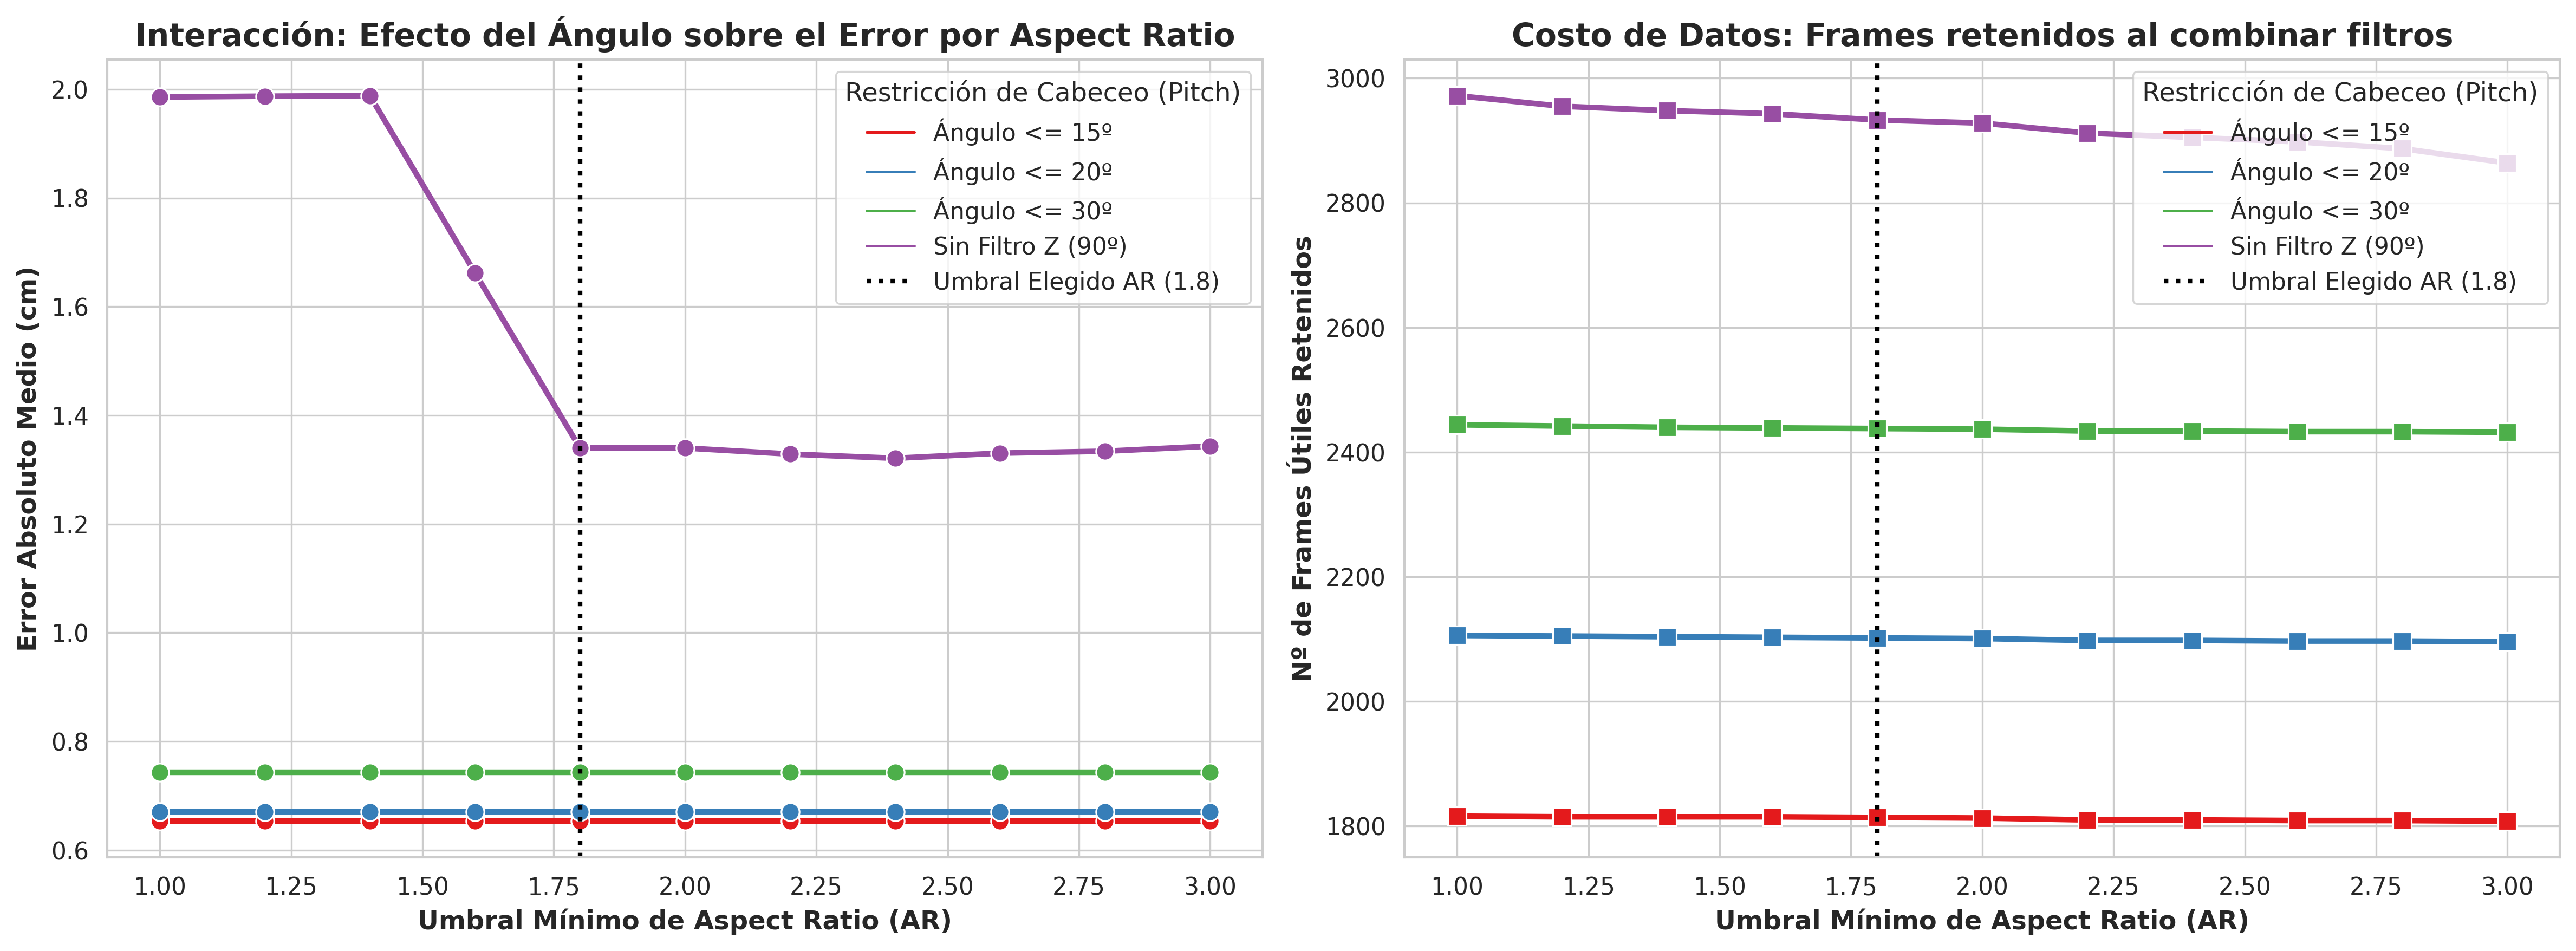

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm # Para ver la barra de progreso en Jupyter
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. PREPARAR DATOS BASE
# =====================================================================
df_base = df_raw[
    (df_raw['is_3D_complete'] == True) &
    (df_raw['in_image_borders'] == False) &
    (df_raw['does_overlap'] == False) &
    (df_raw['filtered_length'] > 0)
].copy()

# =====================================================================
# 2. FUNCIÓN DE EVALUACIÓN
# =====================================================================
def evaluate_thresholds(df, ar_thr, angle_thr):
    df_filt = df[(df['aspect_ratio'] >= ar_thr) & (df['elevation_deg'].abs() <= angle_thr)]
    if df_filt.empty: return np.nan, 0, 0
    
    df_agg = df_filt.groupby(['source_folder', 'track_id']).apply(smart_aggregator).dropna().reset_index()
    if df_agg.empty: return np.nan, 0, 0
    
    mean_err = df_agg['abs_error_cm'].mean()
    retained_frames = len(df_filt)
    retained_tracks = len(df_agg)
    
    return mean_err, retained_frames, retained_tracks


def plot_triple_axis(ax, x_data, y_error, y_frames, y_tracks, title, xlabel, optimal_x):
    # Eje Izquierdo: Error (Azul)
    color_err = '#1f77b4' 
    ax.plot(x_data, y_error, marker='o', color=color_err, linewidth=2.5, label='Error Absoluto (cm)')
    ax.set_xlabel(xlabel, fontweight='bold')
    ax.set_ylabel('Error Absoluto Medio (cm)', color=color_err, fontweight='bold')
    ax.tick_params(axis='y', labelcolor=color_err)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # Eje Derecho 1: Frames (Rojo)
    ax2 = ax.twinx()
    color_frames = '#d62728' 
    ax2.plot(x_data, y_frames, marker='s', color=color_frames, linestyle='--', linewidth=2, label='Frames Retenidos')
    ax2.set_ylabel('Nº de Frames Retenidos', color=color_frames, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_frames)
    
    # Eje Derecho 2: TRACKS (Verde) desplazado hacia afuera
    ax3 = ax.twinx()
    ax3.spines['right'].set_position(('outward', 65)) # Aleja este eje 65 píxeles a la derecha
    color_tracks = '#2ca02c'
    ax3.plot(x_data, y_tracks, marker='^', color=color_tracks, linestyle='-.', linewidth=2, label='Peces (Tracks) Retenidos')
    ax3.set_ylabel('Nº de Peces Retenidos', color=color_tracks, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor=color_tracks)
    
    # Marcar el punto óptimo
    ax.axvline(x=optimal_x, color='black', linestyle=':', linewidth=2, label=f'Umbral Elegido ({optimal_x})')
    
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    
    # Juntar leyendas de los tres ejes
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    lines_3, labels_3 = ax3.get_legend_handles_labels()
    
    # Ponemos la leyenda combinada en el mejor sitio del eje principal
    ax.legend(lines_1 + lines_2 + lines_3, labels_1 + labels_2 + labels_3, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# =====================================================================
# 1. RECOPILAR DATOS COMBINADOS
# =====================================================================
print("Calculando interacción entre Aspect Ratio y Ángulo...")

ar_range = np.arange(1.0, 3.2, 0.2)
# Probamos tu ángulo óptimo (20), uno más estricto (15), uno más relajado (30) y sin filtro (90)
angles_to_test = [15, 20, 30, 90] 

results = []

for ang in tqdm(angles_to_test, desc="Evaluando Ángulos"):
    for ar in ar_range:
        err, frames, tracks = evaluate_thresholds(df_base, ar_thr=ar, angle_thr=ang)
        
        # Etiqueta para la leyenda
        if ang == 90:
            ang_label = "Sin Filtro Z (90º)"
        else:
            ang_label = f"Ángulo <= {ang}º"
            
        results.append({
            'Angle_Thr': ang_label,
            'AR_Thr': ar,
            'Error_cm': err,
            'Frames': frames,
            'Tracks': tracks
        })

df_interaction = pd.DataFrame(results)

# =====================================================================
# 2. PLOTEAR INTERACCIÓN (PAPER-READY)
# =====================================================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Paleta de colores: que resalte bien la diferencia entre líneas
palette = sns.color_palette("Set1", n_colors=len(angles_to_test))

# --- PANEL IZQUIERDO: ERROR ABSOLUTO ---
sns.lineplot(data=df_interaction, x='AR_Thr', y='Error_cm', hue='Angle_Thr', 
             marker='o', markersize=8, linewidth=2.5, palette=palette, ax=axes[0])

axes[0].axvline(x=1.8, color='black', linestyle=':', linewidth=2, label='Umbral Elegido AR (1.8)')
axes[0].set_title("Interacción: Efecto del Ángulo sobre el Error por Aspect Ratio", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Umbral Mínimo de Aspect Ratio (AR)", fontweight='bold')
axes[0].set_ylabel("Error Absoluto Medio (cm)", fontweight='bold')
axes[0].legend(title="Restricción de Cabeceo (Pitch)")

# --- PANEL DERECHO: FRAMES RETENIDOS ---
sns.lineplot(data=df_interaction, x='AR_Thr', y='Frames', hue='Angle_Thr', 
             marker='s', markersize=8, linewidth=2.5, palette=palette, ax=axes[1])

axes[1].axvline(x=1.8, color='black', linestyle=':', linewidth=2, label='Umbral Elegido AR (1.8)')
axes[1].set_title("Costo de Datos: Frames retenidos al combinar filtros", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Umbral Mínimo de Aspect Ratio (AR)", fontweight='bold')
axes[1].set_ylabel("Nº de Frames Útiles Retenidos", fontweight='bold')
axes[1].legend(title="Restricción de Cabeceo (Pitch)")

plt.tight_layout()
plt.show()



In [ ]:
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator # Para que el eje X solo muestre números enteros

def plot_track_evolution(df, folder_code, track_id, ar_thr=1.8):
    """
    Plotea la evolución temporal de las medidas RAW vs FILTRADAS de un pez específico.
    """
    # 1. Búsqueda segura
    folder_str = str(folder_code)
    track_str = str(track_id)
    
    mask = (df['source_folder'].astype(str) == folder_str) & (df['track_id'].astype(str) == track_str)
    fish_data = df[mask].copy()
    
    if fish_data.empty:
        print(f"❌ ERROR: No se encontraron datos para la carpeta '{folder_str}' y track '{track_str}'")
        return
        
    # --- LA SOLUCIÓN AL ERROR ---
    # Extraemos solo los dígitos del frame_id y lo convertimos a número entero.
    # Así "frame_0015" o "15" se convierte en el número matemático 15.
    fish_data['frame_num'] = fish_data['frame_id'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
    
    # 3. Ordenamos temporalmente de verdad (el 2 irá antes que el 10)
    fish_data = fish_data.sort_values(by='frame_num')
    
    gt_cm = fish_data['gt'].iloc[0]
    gt_m = gt_cm / 100.0 if gt_cm > 0 else None
    
    # 4. PLOT
    plt.figure(figsize=(12, 6))
    
    # Ploteamos Raw Length usando el frame_num matemático en el EJE X
    plt.plot(fish_data['frame_num'], fish_data['raw_length'], 
             marker='o', linestyle='-', color='orange', alpha=0.6, label='Raw Length 3D')
    
    # Ploteamos Filtered Length
    plt.plot(fish_data['frame_num'], fish_data['filtered_length'], 
             marker='s', linestyle='-', color='blue', alpha=0.8, label='Filtered Length (HDBSCAN)')
    
    if gt_m is not None:
        plt.axhline(y=gt_m, color='green', linestyle='--', linewidth=2.5, 
                    label=f'Ground Truth ({gt_m:.3f} m)')
        
    # Sombrear las zonas malas
    is_3d_ok = fish_data['is_3D_complete'].fillna(False).astype(bool)
    is_ar_ok = fish_data['aspect_ratio'].fillna(0) >= ar_thr
    
    perfect_mask = is_3d_ok & is_ar_ok
    bad_frames = fish_data[~perfect_mask]['frame_num'] # Extraemos el número matemático
    
    # Ahora sí podemos restar 0.5 sin que explote
    for bf in bad_frames:
        plt.axvspan(bf - 0.5, bf + 0.5, color='red', alpha=0.1)
        
    # Parche invisible para la leyenda
    red_patch = mpatches.Patch(color='red', alpha=0.1, label='Frame Descartado (Filtros no superados)')
    handles, labels = plt.gca().get_legend_handles_labels()
    handles.append(red_patch)

    plt.title(f"Evolución Temporal de las Medidas - [Carpeta: {folder_str} | Track ID: {track_str}]", fontsize=14, fontweight='bold')
    plt.xlabel("Número de Frame", fontsize=12, fontweight='bold')
    plt.ylabel("Longitud Medida (Metros)", fontsize=12, fontweight='bold')
    
    # Forzamos que el eje X muestre números de frame exactos (no decimales como frame 12.5)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(handles=handles, loc='best')
    plt.tight_layout()
    plt.show()

# EJEMPLO DE USO 
# plot_track_evolution(df_raw, "12_07_31_0", 1)

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, MultipleLocator

def plot_track_evolution_detailed(df, folder_code, track_id, ar_thr=1.8, angle_thr=20.0):
    """
    Plotea la evolución temporal de la medida, el aspect ratio y el ángulo de elevación.
    """
    folder_str = str(folder_code)
    track_str = str(track_id)
    
    mask = (df['source_folder'].astype(str) == folder_str) & (df['track_id'].astype(str) == track_str)
    fish_data = df[mask].copy()
    
    if fish_data.empty:
        print(f"❌ ERROR: No se encontraron datos para la carpeta '{folder_str}' y track '{track_str}'")
        return
        
    # Extraer frame matemático
    fish_data['frame_num'] = fish_data['frame_id'].astype(str).str.extract(r'(\d+)').astype(float).astype(int)
    fish_data = fish_data.sort_values(by='frame_num')
    
    gt_cm = fish_data['gt'].iloc[0]
    gt_m = gt_cm / 100.0 if gt_cm > 0 else None
    
    # Encontrar frames malos
    is_3d_ok = fish_data['is_3D_complete'].fillna(False).astype(bool)
    is_ar_ok = fish_data['aspect_ratio'].fillna(0) >= ar_thr
    is_angle_ok = fish_data['elevation_deg'].fillna(90).abs() <= angle_thr
    
    perfect_mask = is_3d_ok & is_ar_ok & is_angle_ok
    bad_frames = fish_data[~perfect_mask]['frame_num']
    
    # --- CREAR LA FIGURA CON 3 PANELES ---
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1, 1]})
    fig.suptitle(f"Análisis Cinemático y Medición - [Carpeta: {folder_str} | Track ID: {track_str}]", fontsize=15, fontweight='bold', y=0.96)
    
    # ==========================================
    # PANEL 1: LONGITUD (Y-lim: 0.05 a 0.45)
    # ==========================================
    ax1 = axes[0]
    ax1.plot(fish_data['frame_num'], fish_data['raw_length'], marker='o', color='orange', alpha=0.6, label='Raw Length 3D')
    ax1.plot(fish_data['frame_num'], fish_data['filtered_length'], marker='s', color='blue', alpha=0.8, label='Filtered Length (HDBSCAN)')
    
    if gt_m is not None:
        ax1.axhline(y=gt_m, color='green', linestyle='--', linewidth=2.5, label=f'Ground Truth ({gt_m:.3f} m)')
    
    ax1.set_ylim(0.05, 0.45)
    # Rejilla detallada cada 5 cm (0.05 m)
    ax1.yaxis.set_major_locator(MultipleLocator(0.05))
    ax1.yaxis.set_minor_locator(MultipleLocator(0.01))
    ax1.grid(True, which='major', linestyle='-', alpha=0.7)
    ax1.grid(True, which='minor', linestyle=':', alpha=0.4)
    
    ax1.set_ylabel("Longitud Medida (m)", fontweight='bold')
    ax1.legend(loc='upper right')
    
    # ==========================================
    # PANEL 2: ASPECT RATIO
    # ==========================================
    ax2 = axes[1]
    ax2.plot(fish_data['frame_num'], fish_data['aspect_ratio'], marker='^', color='purple', linewidth=2)
    ax2.axhline(y=ar_thr, color='black', linestyle=':', linewidth=2, label=f'Umbral AR ({ar_thr})')
    
    ax2.set_ylabel("Aspect Ratio", fontweight='bold')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper right')
    
    # ==========================================
    # PANEL 3: ÁNGULO DE ELEVACIÓN (PITCH)
    # ==========================================
    ax3 = axes[2]
    ax3.plot(fish_data['frame_num'], fish_data['elevation_deg'], marker='v', color='brown', linewidth=2)
    ax3.axhline(y=angle_thr, color='black', linestyle=':', linewidth=2, label=f'Umbral Ángulo (±{angle_thr}º)')
    ax3.axhline(y=-angle_thr, color='black', linestyle=':', linewidth=2)
    
    ax3.set_ylabel("Ángulo Z (º)", fontweight='bold')
    ax3.set_xlabel("Número de Frame", fontsize=12, fontweight='bold')
    ax3.grid(True, linestyle='--', alpha=0.5)
    ax3.legend(loc='upper right')
    
    # ==========================================
    # SOMBREAR FRAMES MALOS EN LOS 3 PANELES
    # ==========================================
    for ax in axes:
        for bf in bad_frames:
            ax.axvspan(bf - 0.5, bf + 0.5, color='red', alpha=0.1)
            
    # Forzar enteros en el eje X compartido
    axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))
    
    plt.tight_layout()
    plt.show()

# EJEMPLO DE USO
# plot_track_evolution_detailed(df_raw, "12_07_31_0", 1)

In [ ]:
df_res_5_angle.sort_values(by="abs_error_cm", ascending=False)\
    .style.format(lambda x: f"{x:.3f}".rstrip('0').rstrip('.') if isinstance(x, float) else x)

,source_folder,track_id,n_frames_validos,calculated_length_cm,gt_cm,abs_error_cm,mean_elevation_deg
18,13_01_16_0,11,12,33.942,28.9,5.042,-3.904
15,12_58_48_0,11,265,32.297,28.9,3.397,3.692
36,pending_13_09_20_0,3,121,30.822,28.9,1.922,-8.045
1,12_52_36_0,12,33,30.386,28.9,1.486,-2.684
37,pending_13_12_31_0,4,280,30.317,28.9,1.417,3.633
21,pending_13_02_27_0,2,29,30.241,28.9,1.341,-1.864
12,12_57_50_0,1,129,30.144,28.9,1.244,-11.193
24,pending_13_02_27_0,42,5,27.736,28.9,1.164,-11.754
35,pending_13_08_33_0,1,37,29.923,28.9,1.023,1.804
20,pending_13_02_27_0,-1,8,29.713,28.9,0.813,-2.264


In [ ]:
df_raw[df_raw["source_folder"]=="2024_11_12-11_37_10-0"]

,source_folder,frame_id,class_name,object_id,track_id,is_3D_complete,in_image_borders,does_overlap,overlapping_fish_ids,fish_direction,...,azimuth_deg,raw_length,filtered_length,spine_length,gt,abs_error_m,rel_error_%,fish_dist_from_camera,aspect_ratio,unique_track


In [ ]:

plot_track_evolution(df_raw,"2024_11_12-10_44_11-0",51)

❌ ERROR: No se encontraron datos para la carpeta '2024_11_12-10_44_11-0' y track '51'


In [ ]:
plot_track_evolution_detailed(df_raw,"12_12_06_compressed",1, ar_thr=2, angle_thr=20.0)

❌ ERROR: No se encontraron datos para la carpeta '12_12_06_compressed' y track '1'
